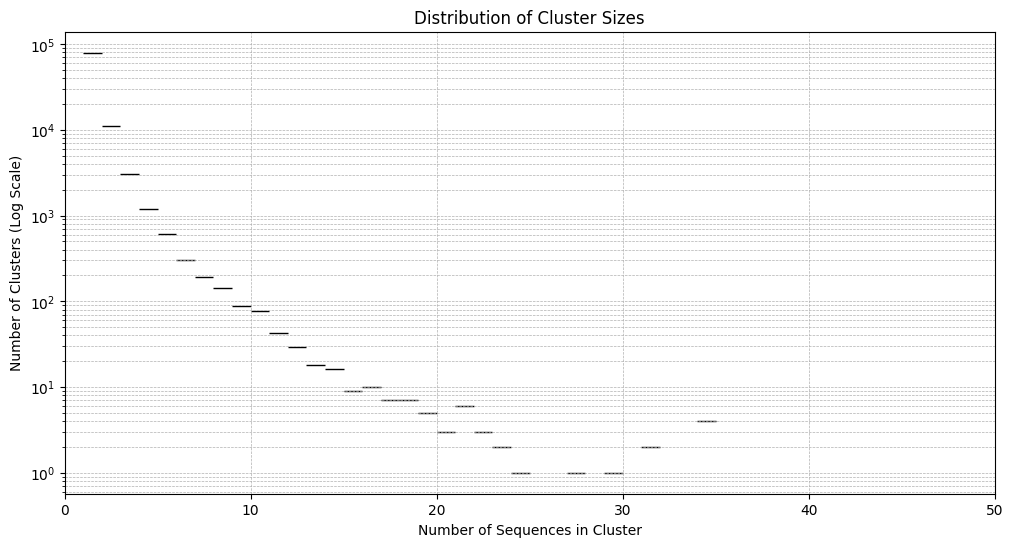

Descriptive Statistics for Cluster Sizes:
count    96375.000000
mean         1.319180
std          1.039514
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         35.000000
dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cluster file
df = pd.read_csv('cluster_results_cluster.tsv', sep='\t', header=None, names=['representative', 'member'])

# Get cluster sizes
cluster_sizes = df.groupby('representative').size()

# --- Plotting ---
plt.figure(figsize=(12, 6))
sns.histplot(cluster_sizes, binwidth=1, log_scale=(False, True)) # Log scale on y-axis is helpful
plt.title('Distribution of Cluster Sizes')
plt.xlabel('Number of Sequences in Cluster')
plt.ylabel('Number of Clusters (Log Scale)')
plt.xlim(0, 50) # Zoom in on smaller cluster sizes if needed
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('cluster_size_distribution.png')
plt.show()

print("Descriptive Statistics for Cluster Sizes:")
print(cluster_sizes.describe())

In [ ]:
import pandas as pd
from Bio import SeqIO
from collections import defaultdict
import random
import os

# --- Configuration ---
FASTA_IN_FILE = 'input_clean.fasta'
CLUSTER_TSV_FILE = 'cluster_results_cluster.tsv'
TRAIN_FASTA_OUT = 'train.fasta'
VAL_FASTA_OUT = 'val.fasta'
# Define the desired train/val split ratio for the *sequences*
TRAIN_RATIO = 0.8 # 80% of sequences in train, 20% in val

# --- 1. Read the cluster TSV and group members by cluster ---
print(f"Reading cluster data from {CLUSTER_TSV_FILE}...")
clusters = defaultdict(list)
total_sequences = 0
with open(CLUSTER_TSV_FILE, 'r') as f:
    for line in f:
        rep, member = line.strip().split('\t')
        clusters[rep].append(member)
        total_sequences += 1

print(f"Found {total_sequences} sequences in {len(clusters)} clusters.")

# --- 2. Implement Cluster-Based Splitting ---
print(f"Splitting clusters to achieve roughly a {TRAIN_RATIO*100:.0f}/{100-TRAIN_RATIO*100:.0f} sequence split.")

# Convert clusters dict to a list of (representative, members) tuples to make it shuffleable
cluster_list = list(clusters.items())
random.shuffle(cluster_list) # Shuffle the list of clusters

train_ids = set()
val_ids = set()
train_cluster_count = 0
val_cluster_count = 0

# Define the target number of sequences for the training set
train_target_size = int(total_sequences * TRAIN_RATIO)

# Iterate through the shuffled clusters and assign them to train or val
for rep, members in cluster_list:
    # If adding the next cluster keeps us under the target size, add it to train
    if len(train_ids) < train_target_size:
        train_ids.update(members)
        train_cluster_count += 1
    else: # Otherwise, assign the cluster to validation
        val_ids.update(members)
        val_cluster_count += 1

print("\nSplit complete.")
print(f"  - Training set: {len(train_ids)} sequences in {train_cluster_count} clusters.")
print(f"  - Validation set: {len(val_ids)} sequences in {val_cluster_count} clusters.")
print(f"  - Actual split ratio: {len(train_ids)/total_sequences*100:.1f}% / {len(val_ids)/total_sequences*100:.1f}%")

# --- 3. Write the new FASTA files using an index for efficiency ---
print(f"\nReading sequences from {FASTA_IN_FILE} and writing splits...")

try:
    sequence_records = SeqIO.index(FASTA_IN_FILE, 'fasta')
except Exception as e:
    print(f"Error indexing FASTA file: {e}")
    print("Please ensure your FASTA file is correctly formatted.")
    exit()

# Write train.fasta
with open(TRAIN_FASTA_OUT, 'w') as f_train:
    for seq_id in train_ids:
        if seq_id in sequence_records:
            SeqIO.write(sequence_records[seq_id], f_train, 'fasta')

# Write val.fasta
with open(VAL_FASTA_OUT, 'w') as f_val:
    for seq_id in val_ids:
        if seq_id in sequence_records:
            SeqIO.write(sequence_records[seq_id], f_val, 'fasta')

print(f"\nSuccessfully created {TRAIN_FASTA_OUT} and {VAL_FASTA_OUT}.")

Reading cluster data from cluster_results_cluster.tsv...
Found 127136 sequences in 96375 clusters.
Splitting clusters to achieve roughly a 80/20 sequence split.

Split complete.
  - Training set: 101708 sequences in 77232 clusters.
  - Validation set: 25428 sequences in 19143 clusters.
  - Actual split ratio: 80.0% / 20.0%

Reading sequences from input_clean.fasta and writing splits...

Successfully created train.fasta and val.fasta.


In [3]:
import pandas as pd
from Bio import SeqIO
from collections import defaultdict
import random
import os

# --- Configuration ---
FASTA_IN_FILE = 'input_clean.fasta'
CLUSTER_TSV_FILE = 'cluster_results_cluster.tsv'
TRAIN_FASTA_OUT = 'train_50_50.fasta'
VAL_FASTA_OUT = 'val_50_50.fasta'
# Define the desired train/val split ratio for the *sequences*
TRAIN_RATIO = 0.9 # 80% of sequences in train, 20% in val

# --- 1. Read the cluster TSV and group members by cluster ---
print(f"Reading cluster data from {CLUSTER_TSV_FILE}...")
clusters = defaultdict(list)
total_sequences = 0
with open(CLUSTER_TSV_FILE, 'r') as f:
    for line in f:
        rep, member = line.strip().split('\t')
        clusters[rep].append(member)
        total_sequences += 1

print(f"Found {total_sequences} sequences in {len(clusters)} clusters.")

# --- 2. Implement Cluster-Based Splitting ---
print(f"Splitting clusters to achieve roughly a {TRAIN_RATIO*100:.0f}/{100-TRAIN_RATIO*100:.0f} sequence split.")

# Convert clusters dict to a list of (representative, members) tuples to make it shuffleable
cluster_list = list(clusters.items())
random.shuffle(cluster_list) # Shuffle the list of clusters

train_ids = set()
val_ids = set()
train_cluster_count = 0
val_cluster_count = 0

for rep, members in cluster_list:
    members = list(members)
    random.shuffle(members)

    if len(members) == 1:
        # Assign single-member clusters to training
        train_ids.update(members)
        train_cluster_count += 1
    else:
        # Split members roughly equally between train and val
        split_idx = len(members) // 2
        train_members = members[:split_idx]
        val_members = members[split_idx:]

        train_ids.update(train_members)
        val_ids.update(val_members)

        train_cluster_count += 1  # still count as one cluster in each set
        val_cluster_count += 1

print("\nSplit complete.")
print(f"  - Training set: {len(train_ids)} sequences in {train_cluster_count} clusters.")
print(f"  - Validation set: {len(val_ids)} sequences in {val_cluster_count} clusters.")
print(f"  - Actual split ratio: {len(train_ids)/total_sequences*100:.1f}% / {len(val_ids)/total_sequences*100:.1f}%")

# --- 3. Write the new FASTA files using an index for efficiency ---
print(f"\nReading sequences from {FASTA_IN_FILE} and writing splits...")

try:
    sequence_records = SeqIO.index(FASTA_IN_FILE, 'fasta')
except Exception as e:
    print(f"Error indexing FASTA file: {e}")
    print("Please ensure your FASTA file is correctly formatted.")
    exit()

# Write train.fasta
with open(TRAIN_FASTA_OUT, 'w') as f_train:
    for seq_id in train_ids:
        if seq_id in sequence_records:
            SeqIO.write(sequence_records[seq_id], f_train, 'fasta')

# Write val.fasta
with open(VAL_FASTA_OUT, 'w') as f_val:
    for seq_id in val_ids:
        if seq_id in sequence_records:
            SeqIO.write(sequence_records[seq_id], f_val, 'fasta')

print(f"\nSuccessfully created {TRAIN_FASTA_OUT} and {VAL_FASTA_OUT}.")



Reading cluster data from cluster_results_cluster.tsv...
Found 127136 sequences in 96375 clusters.
Splitting clusters to achieve roughly a 90/10 sequence split.

Split complete.
  - Training set: 101193 sequences in 96375 clusters.
  - Validation set: 25943 sequences in 17058 clusters.
  - Actual split ratio: 79.6% / 20.4%

Reading sequences from input_clean.fasta and writing splits...

Successfully created train_50_50.fasta and val_50_50.fasta.
